In [36]:
import numpy as np
import pandas as pd

df = pd.read_csv("AmesHousing.csv")

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1578,916386080,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500
1,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000


# Assignment 1
Robert, Borgar & Oskar.

## Exploring the AmesHousing Dataset
We find the structure and basic information of the AmesHousing dataset using df.info() and a preview of the first few rows using df.head(). we find our target variable SalePrice as the last column. thats what we are trying to predict. we need to split the data into training and testing sets and keep them seperate


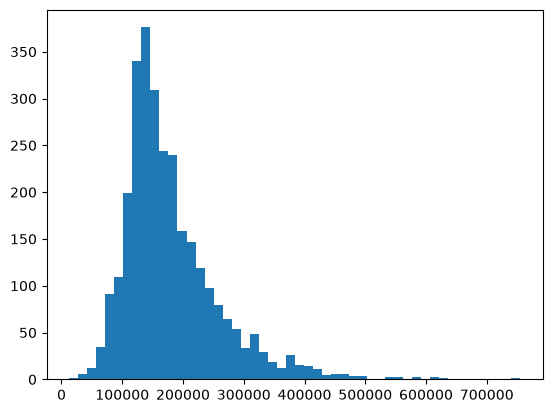

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [10]:
# lets first just get a look at the range of the target variable SalePrice
#creating a histogram to visualize the distribution of SalePrice
import matplotlib.pyplot as plt
plt.hist(df['SalePrice'], bins=50)
plt.show()

df['SalePrice'].describe()

We see the distribution of the target variable SalePrice through the histogram and its summary statistics using df['SalePrice'].describe(). most of the prices center around the 160000 mark. There are also some higher-priced outliers that extend the range significantly.
we also observe that there are some extreme high-priced outliers. we will discuss this later when we consider data preprocessing and potential outlier treatment.

## dropping identifier columns



In [37]:
# Drop unnecessary columns from the DataFrame, that we know are just identifiers
df.drop(columns=["Order","PID"], inplace=True)
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500
1,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000


## Missing values


In [ ]:
#lets check for missing values in the dataset and see which columns have them
missing_values_df = df.isnull().sum()
missing_values_df = missing_values_df[missing_values_df > 0]
missing_values_df = missing_values_df.sort_values(ascending=False)
missing_values_df

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

Just because the value is missing doesnt mean that its not important. in the guide for the dataset it made it clear that missing values often means that that entry does not have that particualr feature, e.g. pool qc. most of the houses do not have a pool, so the pool qc column will have many missing values. This is different from a missing value due to data collection errors, and should be treated accordingly. and many of the garage-related columns will have missing values for houses without garages, explaining the same value missing values in these collomns.

## splitting
given that information it seems that this dataset is very complete, with few actual missing values. we can proceed with splitting the data into training and testing sets.

In [ ]:

from sklearn.model_selection import train_test_split
training, testing = train_test_split(df, test_size=0.2, random_state=42)
testing.info()


<class 'pandas.DataFrame'>
Index: 586 entries, 1357 to 1488
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      586 non-null    int64  
 1   MS Zoning        586 non-null    str    
 2   Lot Frontage     479 non-null    float64
 3   Lot Area         586 non-null    int64  
 4   Street           586 non-null    str    
 5   Alley            29 non-null     str    
 6   Lot Shape        586 non-null    str    
 7   Land Contour     586 non-null    str    
 8   Utilities        586 non-null    str    
 9   Lot Config       586 non-null    str    
 10  Land Slope       586 non-null    str    
 11  Neighborhood     586 non-null    str    
 12  Condition 1      586 non-null    str    
 13  Condition 2      586 non-null    str    
 14  Bldg Type        586 non-null    str    
 15  House Style      586 non-null    str    
 16  Overall Qual     586 non-null    int64  
 17  Overall Cond     586 non-nul

In [44]:

training.info()

<class 'pandas.DataFrame'>
Index: 2344 entries, 381 to 860
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2344 non-null   int64  
 1   MS Zoning        2344 non-null   str    
 2   Lot Frontage     1961 non-null   float64
 3   Lot Area         2344 non-null   int64  
 4   Street           2344 non-null   str    
 5   Alley            169 non-null    str    
 6   Lot Shape        2344 non-null   str    
 7   Land Contour     2344 non-null   str    
 8   Utilities        2344 non-null   str    
 9   Lot Config       2344 non-null   str    
 10  Land Slope       2344 non-null   str    
 11  Neighborhood     2344 non-null   str    
 12  Condition 1      2344 non-null   str    
 13  Condition 2      2344 non-null   str    
 14  Bldg Type        2344 non-null   str    
 15  House Style      2344 non-null   str    
 16  Overall Qual     2344 non-null   int64  
 17  Overall Cond     2344 non-nul

## Correlations
LEts check the correlation between different features and the SalePrice to get a picture of some good predictors.

In [45]:
train_df = training.copy()
# Calculate correlations of all numeric features with SalePrice to identify strong predictors
correlations = (train_df.select_dtypes(include="number").corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False))

display(correlations.to_frame(name="Correlation with SalePrice"))

,Correlation with SalePrice
Overall Qual,0.801082
Gr Liv Area,0.718347
Garage Cars,0.655356
Garage Area,0.654912
Total Bsmt SF,0.639247
1st Flr SF,0.622906
Year Built,0.560365
Full Bath,0.559165
Year Remod/Add,0.542538
Garage Yr Blt,0.530310


In [46]:
categorical_cols = [
    "Neighborhood",
    "Condition 1",
    "Condition 2",
    "Bldg Type",
    "House Style"
]

for col in categorical_cols:
    print(f"\nSalePrice by {col}")

    summary = (
        train_df.groupby(col, dropna=False, observed=True)["SalePrice"]
        .agg(["count", "median", "mean"])
        .sort_values("median", ascending=False)
        .round(0)
    )

    display(summary)


SalePrice by Neighborhood


,count,median,mean
Neighborhood,,,
GrnHill,1,330000.0,330000.0
NridgHt,129,318061.0,321182.0
StoneBr,43,318000.0,322570.0
NoRidge,61,301500.0,321929.0
Veenker,17,255000.0,242968.0
Timber,61,232500.0,249015.0
Somerst,137,222000.0,226879.0
CollgCr,217,200000.0,203302.0
Crawfor,82,199800.0,205393.0



SalePrice by Condition 1


,count,median,mean
Condition 1,,,
RRNn,7,220000.0,212179.0
PosA,16,208000.0,240522.0
PosN,31,200000.0,249932.0
RRAn,37,169985.0,182162.0
Norm,2033,165000.0,183165.0
Feedr,124,137000.0,141591.0
RRAe,20,132750.0,134445.0
Artery,72,123050.0,131254.0
RRNe,4,109925.0,118462.0



SalePrice by Condition 2


,count,median,mean
Condition 2,,,
PosA,3,392000.0,390667.0
PosN,4,359500.0,342938.0
RRAe,1,190000.0,190000.0
Norm,2318,160750.0,180084.0
RRAn,1,136905.0,136905.0
Feedr,11,127000.0,125582.0
Artery,4,123125.0,121812.0
RRNn,2,96750.0,96750.0



SalePrice by Bldg Type


,count,median,mean
Bldg Type,,,
TwnhsE,180,180000.0,191232.0
1Fam,1943,165000.0,184214.0
Duplex,89,136500.0,141988.0
Twnhs,82,132000.0,135265.0
2fmCon,50,122250.0,125767.0



SalePrice by House Style


,count,median,mean
House Style,,,
2.5Fin,8,194000.0,220000.0
2Story,700,190000.0,207609.0
2.5Unf,19,161900.0,183989.0
SLvl,108,161250.0,163105.0
1Story,1170,153250.0,177438.0
SFoyer,65,145500.0,146046.0
1.5Fin,257,129900.0,137114.0
1.5Unf,17,112500.0,107976.0


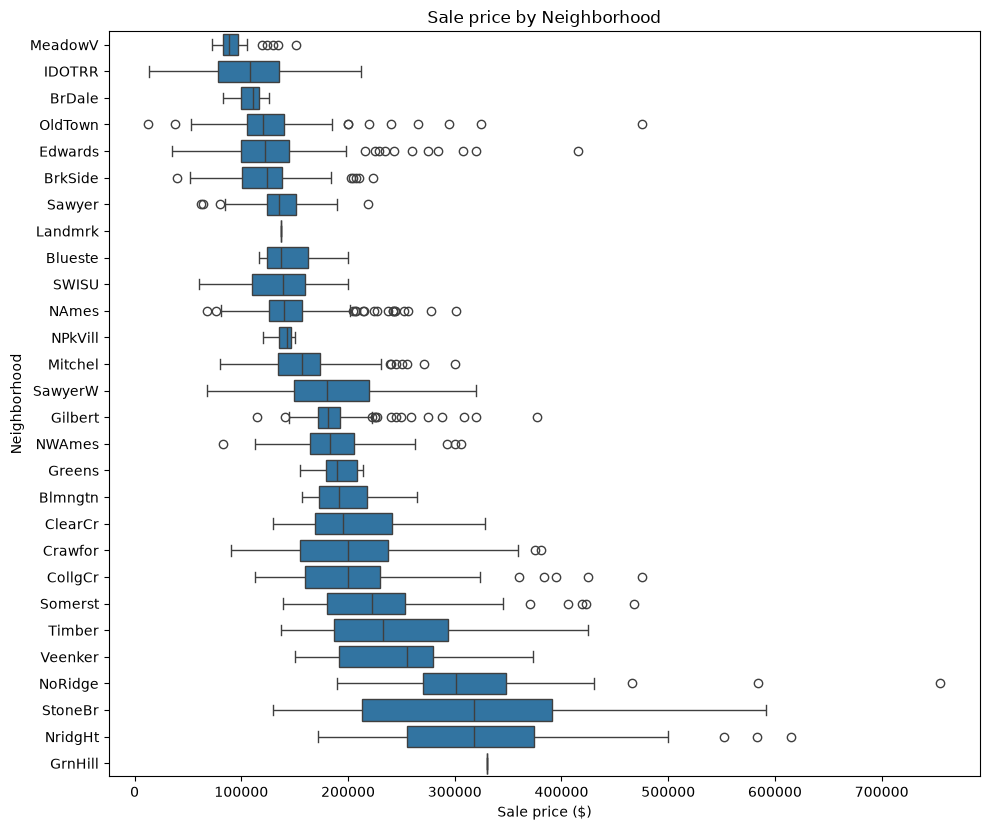

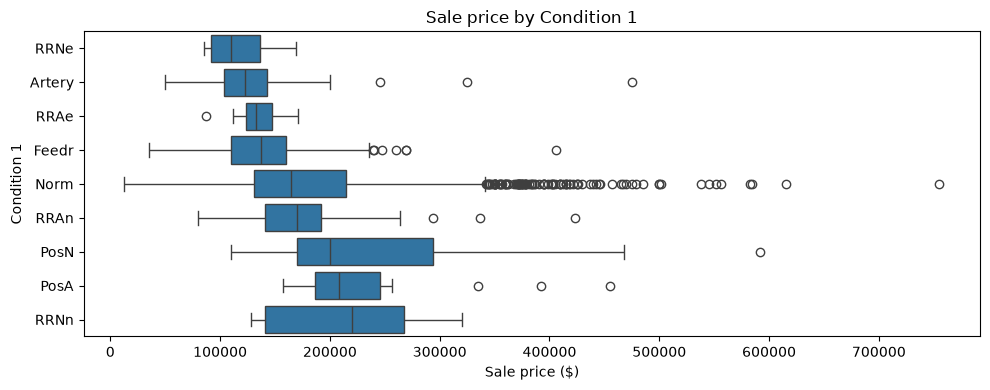

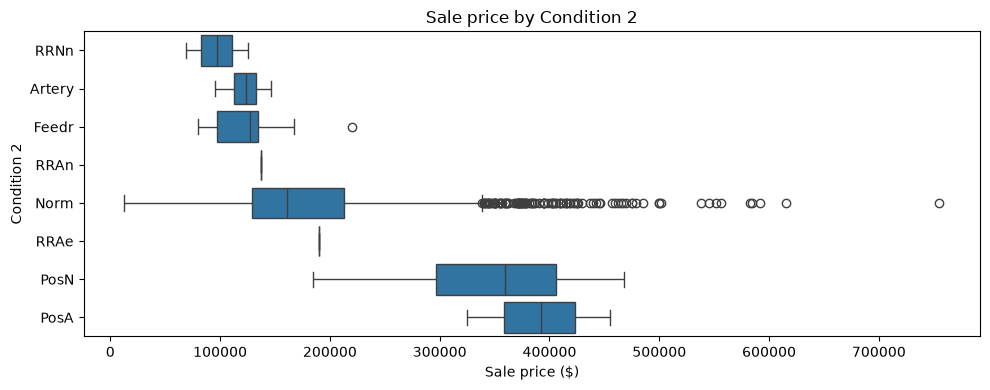

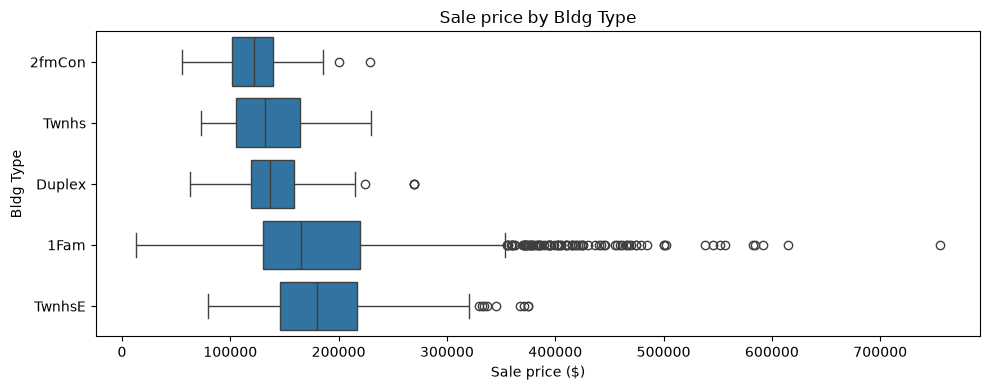

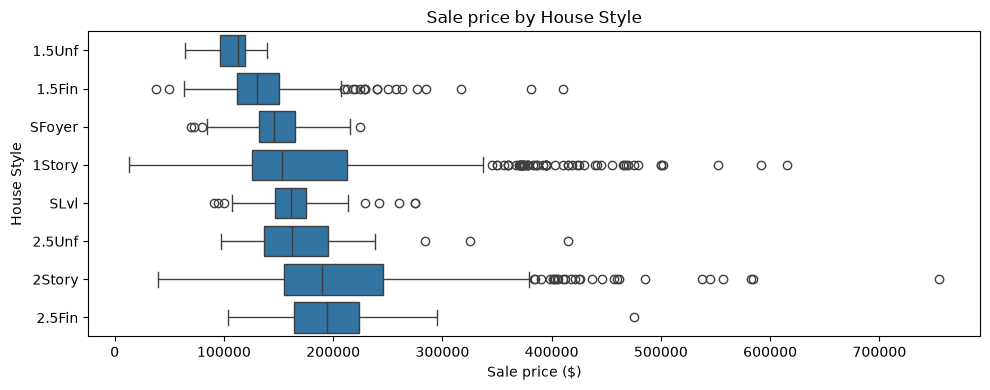

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in categorical_cols:
    order = (train_df.groupby(col, observed=True)["SalePrice"].median().sort_values().index)

    plt.figure(figsize=(10, max(4, len(order) * 0.3)))

    sns.boxplot(data=train_df,x="SalePrice",y=col,order=order)

    plt.title(f"Sale price by {col}")
    plt.xlabel("Sale price ($)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()